In [51]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings('ignore')

In [52]:
fees= pd.read_csv('./data/extract - fees - data analyst - .csv')
cash= pd.read_csv('./data/extract - cash request - data analyst.csv')

In [53]:
# Categorize payment methods
fees['payment_method_label'] = fees['type'].apply(lambda x: 'instant_payment' if x == 'instant_payment' else 'other')

# Count the number of instant payments per user_id
instant_payment_counts = fees[fees['payment_method_label'] == 'instant_payment'].groupby("cash_request_id").size().reset_index(name="instant_payment_count")

In [54]:
merged_df = fees.merge(cash , right_on='id' , left_on='cash_request_id', suffixes=('_fees', '_cash') , how='left')
merged_df = merged_df.merge(instant_payment_counts, on="cash_request_id", how="left")
merged_df["instant_payment_count"] = merged_df["instant_payment_count"].fillna(0)

In [55]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21061 entries, 0 to 21060
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id_fees                     21061 non-null  int64  
 1   cash_request_id             21057 non-null  float64
 2   type                        21061 non-null  object 
 3   status_fees                 21061 non-null  object 
 4   category                    2196 non-null   object 
 5   total_amount                21061 non-null  float64
 6   reason                      21061 non-null  object 
 7   created_at_fees             21061 non-null  object 
 8   updated_at_fees             21061 non-null  object 
 9   paid_at                     15531 non-null  object 
 10  from_date                   7766 non-null   object 
 11  to_date                     7766 non-null   object 
 12  charge_moment               21061 non-null  object 
 13  payment_method_label        210

In [56]:
# create a binary flag column for deleted accounts 0: not deleted , 1: deleted
merged_df['deleted_account_flag'] = merged_df['deleted_account_id'].notna().astype(int)
# impute the user_id null values with the deleted_account_values
if 'deleted_account_id' in merged_df.columns and 'user_id' in merged_df.columns:
    merged_df['user_id'].fillna(merged_df['deleted_account_id'], inplace=True)

# drop 'deleted_account_id'
merged_df['user_id'] = merged_df['user_id'].drop(columns=['deleted_account_id'])


In [57]:
# create a categorical field for the 
merged_df['fees_rejeted'] = merged_df.groupby('cash_request_id')['category'].count()
merged_df['fees_rejeted']= merged_df['fees_rejeted'].fillna(0)
merged_df['fees_rejeted']=merged_df['fees_rejeted'].sort_values()
merged_df['fees_rejeted'].unique()
bins = [0 ,2, 5]
labels =['Low' , 'High']
merged_df['fees_rejection_segment'] = pd.cut(merged_df['fees_rejeted'] , bins = bins , labels = labels, include_lowest = True  )

In [58]:
customer_profitability = merged_df.groupby('user_id').agg(
    total_revenue =('amount', 'sum'), 
    total_fees = ('total_amount', 'sum'),
    transaction_counts =('id_fees', 'count'), 
    fees_rejeted_counts =( 'fees_rejeted' , 'count'), 
    instant_payments =('instant_payment_count', 'sum')
).reset_index()
customer_profitability.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9150 entries, 0 to 9149
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              9150 non-null   float64
 1   total_revenue        9150 non-null   float64
 2   total_fees           9150 non-null   float64
 3   transaction_counts   9150 non-null   int64  
 4   fees_rejeted_counts  9150 non-null   int64  
 5   instant_payments     9150 non-null   float64
dtypes: float64(4), int64(2)
memory usage: 429.0 KB


In [59]:
# Drop unnecessary or duplicate columns
columns_to_drop = [
    "id_fees", "id_cash", "reason", "created_at_fees", "updated_at_fees", "paid_at",
    "from_date", "to_date", "charge_moment", "created_at_cash", "updated_at_cash",
    "moderated_at", "reimbursement_date", 
    "cash_request_received_date", "money_back_date", "transfer_type",
    "send_at", "recovery_status", "reco_creation", "reco_last_update"
]

In [60]:
merged_df = merged_df.drop(columns=[col for col in columns_to_drop if col in merged_df.columns])

In [61]:
# Calculate net profit 
customer_profitability['net_profit'] = customer_profitability['total_revenue'] - customer_profitability['total_fees']

In [62]:
# Customer lifetime value is a measurement of how valuable a customer is to your company, not just on a purchase-by-purchase basis but across entire customer relationships.
customer_profitability['clv'] = customer_profitability['net_profit'] * customer_profitability['transaction_counts']

In [63]:
# Fill missing values
numerical_cols = ['total_revenue', 'total_fees', 'transaction_counts' , 'clv' , 'fees_rejeted_counts' ,'instant_payments']
customer_profitability[numerical_cols] =customer_profitability[numerical_cols].fillna(customer_profitability[numerical_cols ].median())

In [64]:
# Sort customers by profitability
customer_profitability = customer_profitability.sort_values(by="net_profit", ascending=False)

# Display the top profitable customers
print(customer_profitability.head(10))

      user_id  total_revenue  total_fees  transaction_counts  \
1631  16391.0         3700.0       185.0                  37   
657    7731.0         3000.0       150.0                  30   
1543  15593.0         2800.0       140.0                  28   
225    3045.0         2500.0       125.0                  25   
32      528.0         2200.0       110.0                  22   
974   10568.0         2100.0       105.0                  21   
2292  21934.0         2000.0       100.0                  20   
2104  20447.0         1900.0        95.0                  19   
1100  11648.0         1900.0        95.0                  19   
744    8649.0         1800.0        90.0                  18   

      fees_rejeted_counts  instant_payments  net_profit       clv  
1631                   37              36.0      3515.0  130055.0  
657                    30               6.0      2850.0   85500.0  
1543                   28               0.0      2660.0   74480.0  
225                    

In [65]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
customer_profitability[numerical_cols + ["net_profit", "clv"]] = scaler.fit_transform(
    customer_profitability[numerical_cols + ["net_profit", "clv"]]
)

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

def regression_model_evaluate(df, features, target, exploration_size=0.2, poly_degree=[1,2,3,4,5],
                     alpha=[0.001, 0.01, 0.1, 1, 1.1, 1.5, 2], l1_ratio=0.5, 
                     random_state=42, n_splits=5):
    """
    Evaluate Ridge, Lasso, ElasticNet, and Linear Regression models with polynomial features.
    Includes 95% confidence intervals in the plots.

    Parameters:
    - df: pandas DataFrame, the dataset containing the feature and target columns.
    - features: str, the name of the feature column.
    - target: str, the name of the target column.
    - poly_degree: list, polynomial degrees to test.
    - alpha: list, regularization strengths for Ridge, Lasso, and ElasticNet.
    - l1_ratio: float, the mixing parameter for ElasticNet (0 <= l1_ratio <= 1).
    - n_splits: int, number of folds for cross-validation.
    - random_state: int, random seed for reproducibility.
    - exploration_size: float, proportion of the dataset to include in the extrapolation split.

    Returns:
    - Best model based on the lowest R² train-test gap.
    """
    # Remove NaN values
    df_train = df.dropna()

   # Convert to numpy arrays
    X = np.array(df_train[features])
    y = np.array(df_train[target])
   
    # Splitting data into interpretation and extrapolation sets
    X_interp, X_extrap, y_interp, y_extrap = train_test_split(X, y, test_size=exploration_size, random_state=random_state, shuffle=False)

    # Further splitting into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=random_state, shuffle=True
    )

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    best_model = None
    best_r2score = float("inf")  # Initialize best R² score gap

    for degree in poly_degree:
        best_ridge_alpha, best_lasso_alpha, best_elastic_alpha = None, None, None
        best_ridge_model, best_lasso_model, best_elastic_model, best_linear_model = None, None, None, None
        best_ridge_mse, best_lasso_mse, best_elastic_mse, best_linear_mse = float('inf'), float('inf'), float('inf'), float('inf')

        for a in alpha:  # Use correct variable `a`
            # Ridge Regression
            ridge_model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=a))
            ridge_preds = cross_val_predict(ridge_model, X_train, y_train, cv=kf)
            ridge_mse = mean_squared_error(y_train, ridge_preds)

            if ridge_mse < best_ridge_mse:
                best_ridge_mse = ridge_mse
                best_ridge_alpha = a
                best_ridge_model = ridge_model

            # Lasso Regression
            lasso_model = make_pipeline(PolynomialFeatures(degree), Lasso(alpha=a, max_iter=10000))
            lasso_preds = cross_val_predict(lasso_model, X_train, y_train, cv=kf)
            lasso_mse = mean_squared_error(y_train, lasso_preds)

            if lasso_mse < best_lasso_mse:
                best_lasso_mse = lasso_mse
                best_lasso_alpha = a
                best_lasso_model = lasso_model

            # ElasticNet Regression
            elastic_model = make_pipeline(PolynomialFeatures(degree), ElasticNet(alpha=a, l1_ratio=l1_ratio, max_iter=10000))
            elastic_preds = cross_val_predict(elastic_model, X_train, y_train, cv=kf)
            elastic_mse = mean_squared_error(y_train, elastic_preds)

            if elastic_mse < best_elastic_mse:
                best_elastic_mse = elastic_mse
                best_elastic_alpha = a
                best_elastic_model = elastic_model

        # Linear Regression (No Regularization)
        linear_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        linear_preds = cross_val_predict(linear_model, X_train, y_train, cv=kf)
        best_linear_mse = mean_squared_error(y_train, linear_preds)
        best_linear_model = linear_model

        # Train best models
        best_ridge_model.fit(X_interp, y_interp)
        best_lasso_model.fit(X_interp, y_interp)
        best_elastic_model.fit(X_interp, y_interp)
        best_linear_model.fit(X_interp, y_interp)

        # Compute R² Scores for Train & Test
        R2_ridge_gap = r2_score(y_train, best_ridge_model.predict(X_train)) - r2_score(y_test, best_ridge_model.predict(X_test))
        R2_lasso_gap = r2_score(y_train, best_lasso_model.predict(X_train)) - r2_score(y_test, best_lasso_model.predict(X_test))
        R2_elastic_gap = r2_score(y_train, best_elastic_model.predict(X_train)) - r2_score(y_test, best_elastic_model.predict(X_test))
        R2_linear_gap = r2_score(y_train, best_linear_model.predict(X_train)) - r2_score(y_test, best_linear_model.predict(X_test))

        # Choose the best model based on R² gap minimization
        for model, r2_gap in [(best_ridge_model, R2_ridge_gap), 
                              (best_lasso_model, R2_lasso_gap), 
                              (best_elastic_model, R2_elastic_gap), 
                              (best_linear_model, R2_linear_gap)]:
            if r2_gap < best_r2score:
                best_model = model
                best_r2score = r2_gap

        print(f"Degree {degree}:")
        print(f"  Ridge (α={best_ridge_alpha}, MSE={best_ridge_mse:.4f}), ΔR²={R2_ridge_gap:.4f}")
        print(f"  Lasso (α={best_lasso_alpha}, MSE={best_lasso_mse:.4f}), ΔR²={R2_lasso_gap:.4f}")
        print(f"  ElasticNet (α={best_elastic_alpha}, MSE={best_elastic_mse:.4f}), ΔR²={R2_elastic_gap:.4f}")
        print(f"  Linear Regression (MSE={best_linear_mse:.4f}), ΔR²={R2_linear_gap:.4f}\n")

    return best_model

In [67]:
print(customer_profitability.isna().sum())

user_id                0
total_revenue          0
total_fees             0
transaction_counts     0
fees_rejeted_counts    0
instant_payments       0
net_profit             0
clv                    0
dtype: int64


In [68]:
features =  ['total_revenue', 'total_fees', 'transaction_counts' , 'clv' , 'fees_rejeted_counts', 'instant_payments']
target = 'net_profit'

best_model = regression_model_evaluate(customer_profitability, features, target)

Degree 1:
  Ridge (α=0.001, MSE=0.0000), ΔR²=-0.0000
  Lasso (α=0.001, MSE=0.0003), ΔR²=0.0006
  ElasticNet (α=0.001, MSE=0.0002), ΔR²=-0.0036
  Linear Regression (MSE=0.0000), ΔR²=0.0000

Degree 2:
  Ridge (α=0.001, MSE=0.0000), ΔR²=-0.0000
  Lasso (α=0.001, MSE=0.0003), ΔR²=0.0006
  ElasticNet (α=0.001, MSE=0.0002), ΔR²=-0.0036
  Linear Regression (MSE=0.0000), ΔR²=0.0000

Degree 3:
  Ridge (α=0.001, MSE=0.0000), ΔR²=-0.0000
  Lasso (α=0.001, MSE=0.0003), ΔR²=0.0006
  ElasticNet (α=0.001, MSE=0.0002), ΔR²=-0.0036
  Linear Regression (MSE=0.0000), ΔR²=0.0000

Degree 4:
  Ridge (α=0.001, MSE=0.0000), ΔR²=-0.0000
  Lasso (α=0.001, MSE=0.0003), ΔR²=0.0006
  ElasticNet (α=0.001, MSE=0.0002), ΔR²=-0.0036
  Linear Regression (MSE=0.0000), ΔR²=0.0000

Degree 5:
  Ridge (α=0.001, MSE=0.0000), ΔR²=-0.0000
  Lasso (α=0.001, MSE=0.0003), ΔR²=0.0006
  ElasticNet (α=0.001, MSE=0.0002), ΔR²=-0.0036
  Linear Regression (MSE=0.0000), ΔR²=0.0000



In [69]:
new_customer = np.array([[5000, 300, 12, 25000 , 3 , 5]])  # [total_revenue, total_fees, transaction_count, clv]


new_customer = new_customer.reshape(1, -1)  # (1 sample, 4 features)

# Predict net profit
predicted_profit = best_model.predict(new_customer)
print("Predicted Net Profit:", predicted_profit[0])

Predicted Net Profit: 2045.7746721247086


In [77]:
high_profit_threshold = customer_profitability["net_profit"].quantile(0.75)

customer_profitability["profit_category"] = customer_profitability["net_profit"].apply(
    lambda x: "High Profit" if x >= high_profit_threshold else "Low Profit"
)
print(customer_profitability[["user_id", "net_profit", "profit_category"]])

       user_id  net_profit profit_category
1631   16391.0    1.000000     High Profit
657     7731.0    0.811026     High Profit
1543   15593.0    0.757033     High Profit
225     3045.0    0.676044     High Profit
32       528.0    0.595055     High Profit
...        ...         ...             ...
8425   93036.0    0.002558      Low Profit
7787   87698.0    0.002558      Low Profit
9087  101362.0    0.002558      Low Profit
1081   11473.0    0.000284      Low Profit
8611   94767.0    0.000000      Low Profit

[9150 rows x 3 columns]


In [81]:
high_payment_threshold = customer_profitability["instant_payments"].quantile(0.50)
low_payment_threshold = customer_profitability["instant_payments"].quantile(0.25)
customer_profitability["instant_payment_category"] = customer_profitability["instant_payments"].apply(
    lambda x: "low instant payment" if x <=  high_payment_threshold else
    'Medium instant payment' if  x > low_payment_threshold and  x>  high_payment_threshold  
    else  "High instant payment"
)


In [82]:
high_rejection_threshold = customer_profitability["fees_rejeted_counts"].quantile(0.50)
low_rejection_threshold = customer_profitability["fees_rejeted_counts"].quantile(0.25)
customer_profitability["rejection_category"] = customer_profitability["fees_rejeted_counts"].apply(
    lambda x: "low rejection" if x <=  low_rejection_threshold else
    'Medium Rejection' if  x > low_rejection_threshold and  x<=  high_rejection_threshold 
    else  "High rejection"
)
print(customer_profitability[["user_id", "net_profit", "profit_category" , "rejection_category" , 'instant_payment_category']])

       user_id  net_profit profit_category rejection_category  \
1631   16391.0    1.000000     High Profit     High rejection   
657     7731.0    0.811026     High Profit     High rejection   
1543   15593.0    0.757033     High Profit     High rejection   
225     3045.0    0.676044     High Profit     High rejection   
32       528.0    0.595055     High Profit     High rejection   
...        ...         ...             ...                ...   
8425   93036.0    0.002558      Low Profit      low rejection   
7787   87698.0    0.002558      Low Profit      low rejection   
9087  101362.0    0.002558      Low Profit      low rejection   
1081   11473.0    0.000284      Low Profit      low rejection   
8611   94767.0    0.000000      Low Profit      low rejection   

     instant_payment_category  
1631   Medium instant payment  
657    Medium instant payment  
1543      low instant payment  
225       low instant payment  
32     Medium instant payment  
...                       .

<Axes: xlabel='profit_category', ylabel='Count'>

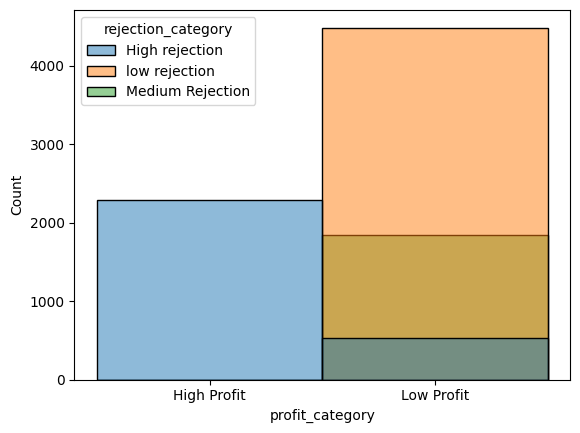

In [83]:
from matplotlib import pyplot as plt 
import seaborn as sns 
sns.histplot(data = customer_profitability , x = 'profit_category'  , hue='rejection_category')


In [84]:
high_rejection_high_profit_user_ids = customer_profitability[(customer_profitability['profit_category']== 'High Profit') & (customer_profitability['rejection_category']== 'High rejection')]

In [85]:
display(high_rejection_high_profit_user_ids)

,user_id,total_revenue,total_fees,transaction_counts,fees_rejeted_counts,instant_payments,net_profit,clv,profit_category,instant_payment_category,rejection_category
1631,16391.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,High Profit,Medium instant payment,High rejection
657,7731.0,0.810760,0.805556,0.805556,0.805556,0.166667,0.811026,0.657425,High Profit,Medium instant payment,High rejection
1543,15593.0,0.756691,0.750000,0.750000,0.750000,0.000000,0.757033,0.572694,High Profit,low instant payment,High rejection
225,3045.0,0.675588,0.666667,0.666667,0.666667,0.027778,0.676044,0.456554,High Profit,low instant payment,High rejection
32,528.0,0.594485,0.583333,0.583333,0.583333,0.583333,0.595055,0.353563,High Profit,Medium instant payment,High rejection
...,...,...,...,...,...,...,...,...,...,...,...
1845,18403.0,0.067315,0.055556,0.055556,0.055556,0.027778,0.067917,0.005451,High Profit,low instant payment,High rejection
308,4411.0,0.067315,0.055556,0.055556,0.055556,0.027778,0.067917,0.005451,High Profit,low instant payment,High rejection
1601,16164.0,0.067315,0.055556,0.055556,0.055556,0.055556,0.067917,0.005451,High Profit,Medium instant payment,High rejection
2595,24744.0,0.067315,0.055556,0.055556,0.055556,0.083333,0.067917,0.005451,High Profit,Medium instant payment,High rejection


In [ ]:
# I want to save this into csv file and then upload it in the late payment file and check if this group is fraudus 

In [88]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
# Encode categorical variables using LabelEncoder
random_seed = 42
label_encoder = LabelEncoder()
high_rejection_high_profit_user_ids['rejection_category'] = label_encoder.fit_transform(high_rejection_high_profit_user_ids['rejection_category'])
high_rejection_high_profit_user_ids['profit_category'] = label_encoder.fit_transform(high_rejection_high_profit_user_ids['profit_category'])
high_rejection_high_profit_user_ids['instant_payment_category'] = label_encoder.fit_transform(high_rejection_high_profit_user_ids['instant_payment_category'])

# Define features (X) and target (y)
X = high_rejection_high_profit_user_ids.drop(columns=['instant_payment_category', 'user_id'])  # Features
y = high_rejection_high_profit_user_ids['instant_payment_category']  # Target variable

# Normalize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Data for Interpolationa, Extrapolation, Train and Test
X_interap, X_extrap, y_interap, y_extrap= train_test_split(X, y, test_size=0.3, random_state= random_seed, shuffle=False)
# X_train, X_test, Y_train, Y_test = train_test_split(X_interap, y_interap, test_size=0.2, random_state=random_seed, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X_interap, y_interap, test_size=0.3, random_state=random_seed, shuffle=True)

In [89]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization strength
    'gamma': [0.01, 0.1, 1, 'scale', 'auto'],  # Kernel coefficient
    'kernel': ['rbf', 'linear', 'poly', 'sigmoid']  # Kernel types
}

# Create SVM model
svm_model = SVC(probability=True)
# Define K-Fold Cross-Validation strategy (Stratified ensures class balance)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Implement GridSearchCV with K-Fold CV
grid_search = GridSearchCV(svm_model, param_grid, cv=kfold, scoring='accuracy', n_jobs=-1, verbose=3)


# Fit on training data
grid_search.fit(X_train, y_train)

# Get the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Get the best model
best_svm_model = grid_search.best_estimator_

# Evaluate the best model on test data
test_accuracy = best_svm_model.score(X_test, y_test)
print("Test Accuracy of Best Model:", test_accuracy)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Hyperparameters: {'C': 100, 'gamma': 0.01, 'kernel': 'linear'}
Test Accuracy of Best Model: 1.0


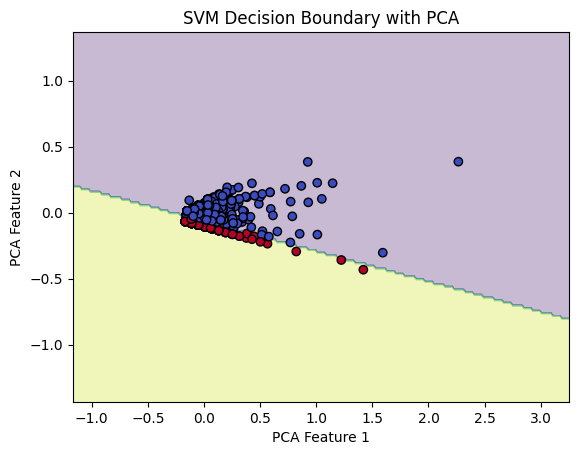

In [90]:
from sklearn.decomposition import PCA
# Reduce features to 2D for visualization
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)  # Transform training data
X_test_pca = pca.transform(X_test)

# Train SVM on PCA-reduced data
svm_pca_best_model = SVC(kernel='linear', C=100, gamma=0.01, probability=True)
svm_pca_best_model.fit(X_train_pca, y_train)

# Visualize the descision area
# Define mesh step size
h_svm = 0.02  

# Extract PCA feature limits
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

# Generate grid points
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h_svm),
    np.arange(y_min, y_max, h_svm)
)

# Predict on mesh grid using SVM trained on PCA data
Z = svm_pca_best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.coolwarm)
plt.xlabel("PCA Feature 1")
plt.ylabel("PCA Feature 2")
plt.title("SVM Decision Boundary with PCA")
plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       382
           1       1.00      1.00      1.00        99

    accuracy                           1.00       481
   macro avg       1.00      1.00      1.00       481
weighted avg       1.00      1.00      1.00       481

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       568
           1       1.00      1.00      1.00       119

    accuracy                           1.00       687
   macro avg       1.00      1.00      1.00       687
weighted avg       1.00      1.00      1.00       687

Confusion Matrix for the test data:


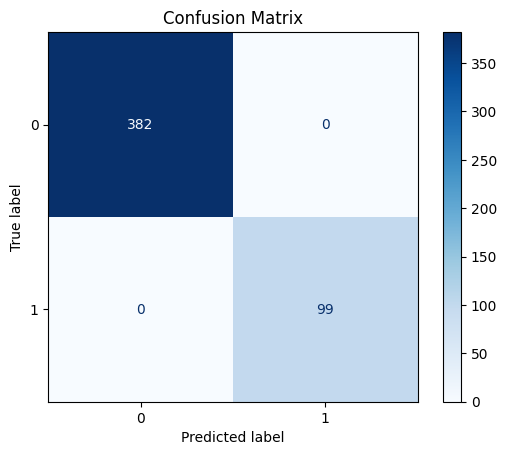

Confusion Matrix for the extrapolation data:


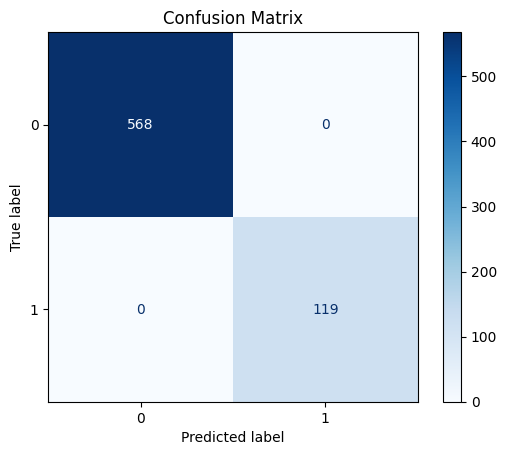

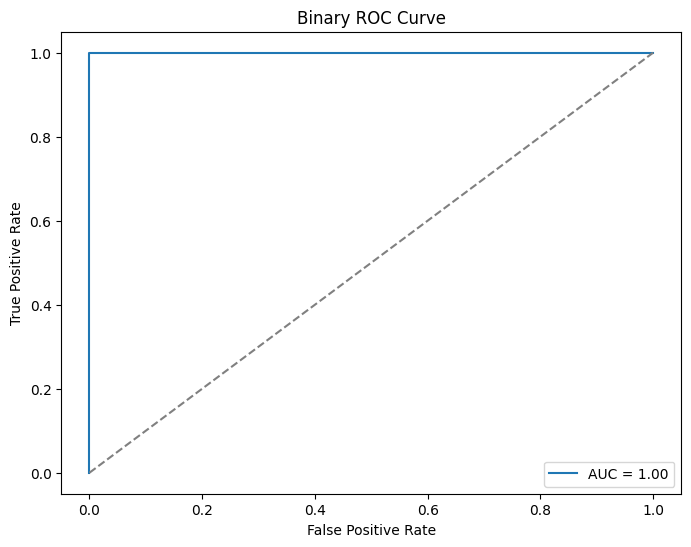

AUC Score for Binary Classification: 1.0000


In [100]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


y_pred_test_svm = best_svm_model.predict(X_test)
y_pred_extrap_svm= best_svm_model.predict(X_extrap)

print('Classification Report:')
print(classification_report(y_test, y_pred_test_svm))
print(classification_report(y_extrap, y_pred_extrap_svm))

cm_matrix_test = confusion_matrix(y_test,y_pred_test_svm)
print('Confusion Matrix for the test data:')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix_test, display_labels=best_svm_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

cm_matrix_extrap = confusion_matrix(y_extrap,y_pred_extrap_svm)
print('Confusion Matrix for the extrapolation data:')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix_extrap, display_labels=best_svm_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


# Ensure y_extrap has multiple classes before binarization
unique_classes = np.unique(y_extrap)

if len(unique_classes) > 2:  # Multi-class case
    y_extrap_bin = label_binarize(y_extrap, classes=unique_classes)  # Convert to binary format
    y_scores = best_svm_model.predict_proba(X_extrap)

    # Plot ROC curve for each class
    plt.figure(figsize=(8, 6))
    auc_scores_extrap = []

    for i in range(len(unique_classes)):  # Loop through valid classes
        fpr, tpr, _ = roc_curve(y_extrap_bin[:, i], y_scores[:, i])  # Compute ROC curve
        roc_auc = auc(fpr, tpr)  # Compute AUC score
        auc_scores_extrap.append(roc_auc)  # Store AUC scores

        # Plot each class separately
        plt.plot(fpr, tpr, label=f'Class {unique_classes[i]} (AUC = {roc_auc:.2f})')

    # Plot diagonal line (random classifier reference)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Multiclass ROC Curve")
    plt.legend()
    plt.show()

    # Print the AUC score for each class
    for i, auc_extrap in enumerate(auc_scores_extrap):
        print(f"AUC of Class {unique_classes[i]}: {auc_extrap:.4f}")

else:  # Binary classification case
    y_scores = best_svm_model.predict_proba(X_extrap)[:, 1]  # Get probability for positive class
    fpr, tpr, _ = roc_curve(y_extrap, y_scores)  # Compute ROC curve
    roc_auc = auc(fpr, tpr)  # Compute AUC score

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Binary ROC Curve")
    plt.legend()
    plt.show()

    print(f"AUC Score for Binary Classification: {roc_auc:.4f}")